# PlantHelixSeek Combined CRE + Anno View (Arabidopsis showcase)

**Display region (illustrative):** `combined_locus=Chr1:5220001-5265000` — the owner-chosen
40 kb display window `Chr1:5220001-5260000` plus a 5 kb downstream flank so edge-crossing
genes complete (e.g. AT1G15290.1 ends at 5264942). This notebook is a DISPLAY VIEW: both
PlantHelixSeek modalities and their truths on one aligned genomic axis (pygenometracks),
for display clarity. The full-locus scans, metrics and tolerance bands live in the two
showcase notebooks ([CRE](../plant_helixseek_cre/plant_helixseek_cre.ipynb) and
[Anno](../plant_helixseek_anno/plant_helixseek_anno.ipynb)) and the frozen contract
[`plant_helixseek_shared/data/selection.md`](data/selection.md) — those remain the
authoritative claims.

**Committed display artifacts (internal preparation steps, not re-done in-notebook):**

- Leaf DNase: `data/Ath_leaf_DNase_chr1_5100001_5300000.bedGraph` — the official PlantDHS
  BigWig (https://plantdhs.org/static/download/Ath_leaf_DNase.bw) extracted 2026-10-04 to
  0-based 50 bp bins aligned to the CRE scan grid; fed directly to the renderer, which
  crops it to the display region.
- TAIR10 truth gene models: `data/TAIR10_GTF_chr1_5100001_5300000.gtf` — deterministic
  pre-converted GTF of the committed TAIR10 GFF3 slice (conversion rule documented in its
  header); fed directly to the renderer.

**Methodology:** the two scans below are transcribed verbatim from the frozen Phase-6
locus-selection contract (selection.md) and the two showcase notebooks — CRE 500/50/50
sliding windows and Anno 8192/4096 both-strand stitching (BOS offset, upstream B<->L
permutation) — restricted to the display region. Model access goes through the dnallm
public route only; forwards run under `torch.no_grad()`.

**Environment:** the exact transformers / torch / flash-linear-attention versions this
notebook ran with are printed by the first code cell as `transformers_version=`,
`torch_version=` and `fla_version=` key=value lines.

**Disclaimer (illustrative locus):** all results in this notebook are computed on ONE
illustrative display region chosen for display clarity. They demonstrate the workflow on
an illustrative locus, not genome-wide accuracy — see selection.md for the selection
methodology and the meaning of each tolerance band.


In [1]:
# Hard environment guard (D-16): the PlantHelixSeek remote code silently falls
# back to a pure-PyTorch non-KDA path when flash-linear-attention is absent,
# producing positionally-dead outputs -- absence is a hard error, never a
# silent degradation. The spec probe is deliberate (never a bare module
# import): the fast-lane test tests/examples/test_examples.py execs every
# import statement in this notebook on legs without the fla extra.
import importlib.metadata
import importlib.util

import torch
import transformers

if importlib.util.find_spec("fla") is None:
    raise RuntimeError(
        "flash-linear-attention (fla) is not installed: the PlantHelixSeek "
        "kernels would silently fall back to the non-KDA path and produce "
        "positionally-dead outputs (see README section Flash-Linear-Attention). "
        "Install with: uv pip install -e '.[fla]'"
    )

# The fla version is read via importlib.metadata.version -- a call, not an
# import statement, so no import node ever names the fla module.
print(f"transformers_version={transformers.__version__}")
print(f"torch_version={torch.__version__}")
print(f"fla_version={importlib.metadata.version('flash-linear-attention')}")
print(f"cuda_device={torch.cuda.get_device_name(0)}")

transformers_version=5.17.0
torch_version=2.11.0+cu130
fla_version=0.5.2
cuda_device=NVIDIA GB10


## Load the display region

The 45 kb display region is carved out of the committed 200 kb locus fragment
(`../plant_helixseek_cre/data/chr1_5100001_5300000.fas`) with the genomic offset parsed from
the FASTA header — never hardcoded twice. The committed bedGraph and truth GTF in `data/`
are referenced directly by the figure cell (no load, no conversion).


In [2]:
import re

from pathlib import Path

from dnallm.utils import fetch_sequence

# Owner-picked display region: the 40 kb window Chr1:5220001-5260000 plus a 5 kb
# downstream flank (through genomic 5265000) so edge-crossing genes complete.
zoom_start, flank_end = 5220000, 5265000  # 0-based half-open display region

fasta_path = Path("../plant_helixseek_cre/data/chr1_5100001_5300000.fas")
header = fasta_path.read_text(encoding="utf-8").splitlines()[0]
locus_match = re.search(r"\[(\d+),\s*(\d+)\]", header)
if locus_match is None:
    raise RuntimeError("FASTA header carries no '[start, end]' genomic interval")
locus_start, locus_end = int(locus_match.group(1)), int(locus_match.group(2))
# Genomic offset (single source: the FASTA header interval, 1-based closed).
genomic_offset = locus_start - 1
assert genomic_offset <= zoom_start and flank_end <= locus_end, "region outside the fragment"

region_length = flank_end - zoom_start
region_seq = fetch_sequence(
    str(fasta_path), "Chr1", zoom_start - genomic_offset + 1, flank_end - genomic_offset
)
assert len(region_seq) == region_length
print(f"combined_locus=Chr1:{zoom_start + 1}-{flank_end}")
print(f"display_region_length={region_length}")


combined_locus=Chr1:5220001-5265000

display_region_length=45000

## Load both checkpoints through the dnallm public route

The packaged registry (`dnallm/models/model_info.yaml`) is the single source of repo ids
and label orders, exactly as in the two showcase notebooks; both checkpoints load through
the generic dnallm dispatch with ModelScope as the source (warm cache).


In [3]:
import dnallm
import yaml

from dnallm.configuration.configs import TaskConfig
from dnallm.models.model import load_model_and_tokenizer

registry_path = Path(dnallm.__file__).parent / "models" / "model_info.yaml"
registry = yaml.safe_load(registry_path.read_text(encoding="utf-8"))


def load_plant_helixseek(repo_id):
    """Load one PlantHelixSeek checkpoint through its packaged registry entry."""
    entries = [e for e in registry["finetuned"] if e.get("model") == repo_id]
    assert len(entries) == 1, f"expected exactly one registry entry for {repo_id}"
    task = entries[0]["task"]
    task_config = TaskConfig(
        task_type=task["task_type"],
        num_labels=task["num_labels"],
        label_names=task["label_names"],
        threshold=task["threshold"],
    )
    model, tokenizer = load_model_and_tokenizer(repo_id, task_config, source="modelscope")
    return task, model, tokenizer


cre_task, cre_model, cre_tokenizer = load_plant_helixseek("zhangtaolab/PlantHelixSeek-CRE")
print(f"cre_model_id2label={cre_model.config.id2label}")
print(f"cre_model_device={cre_model.device}")
anno_task, anno_model, anno_tokenizer = load_plant_helixseek("zhangtaolab/PlantHelixSeek-Anno")
label_names = anno_task["label_names"]
print(f"anno_model_num_labels={anno_model.config.num_labels}")
print(f"anno_model_device={anno_model.device}")


13:01:59 - dnallm.utils.support - 

INFO

 - Model files are stored in /home/forrest/.cache/modelscope/hub/models/zhangtaolab/PlantHelixSeek-CRE


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

cre_model_id2label={0: 'Not CRE', 1: 'CRE'}

...

INFO

 - Model files are stored in /home/forrest/.cache/modelscope/hub/models/zhangtaolab/PlantHelixSeek-Anno


Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

anno_model_num_labels=17

anno_model_device=cuda:0

## CRE scan over the display region

The frozen 500 bp / 50 stride / 50 bp bin sliding scan at batch 4 (the eager-attention
ceiling through the dnallm route), transcribed from the CRE showcase notebook and
restricted to the display region: each bin gets the arithmetic mean p(CRE) of the windows
covering it.


In [4]:
import numpy as np

cre_window, cre_stride, bin_width, batch_size = 500, 50, 50, 4


def scan_bin_scores(seq):
    """Per-bin mean p(CRE) over the 500/50/50 sliding windows at batch 4."""
    starts = list(range(0, len(seq) - cre_window + 1, cre_stride))
    probabilities = []
    with torch.no_grad():
        for i in range(0, len(starts), batch_size):
            batch = [seq[s : s + cre_window] for s in starts[i : i + batch_size]]
            enc = cre_tokenizer(batch, return_tensors="pt", padding=True)
            out = cre_model(
                input_ids=enc["input_ids"].to(cre_model.device),
                attention_mask=enc["attention_mask"].to(cre_model.device),
            )
            p_cre = torch.softmax(out.logits, dim=-1)[:, 1]
            probabilities.extend(p_cre.float().cpu().tolist())
    probabilities = np.asarray(probabilities)

    n_bins = len(seq) // bin_width
    scores = np.zeros(n_bins)
    counts = np.zeros(n_bins, dtype=int)
    for start, p in zip(starts, probabilities):
        scores[start // bin_width : (start + cre_window) // bin_width] += p
        counts[start // bin_width : (start + cre_window) // bin_width] += 1
    # Structural assert: every bin is covered by at least one window.
    assert counts.min() >= 1, f"bin coverage gap: min coverage {counts.min()}"
    return scores / counts


region_bin_scores = scan_bin_scores(region_seq)
print(f"cre_scan_bins={len(region_bin_scores)}")
print(f"cre_bin_score_mean={region_bin_scores.mean():.4f}")


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


HelixSeek requires an initialized cache to return a cache. None was provided, so no cache will be returned.


cre_scan_bins=900

cre_bin_score_mean=0.2458

## Anno scan over the display region

The frozen 8192 bp / 4096 stride both-strand scan at batch 1, transcribed from the Anno
showcase notebook and restricted to the display region: stride windows plus a tail window,
per-base argmax labels with the BOS offset, stitched into each window's core; the minus
strand scans reverse complements and applies the upstream B<->L permutation before
reversing to plus-strand coordinates. The two strand tracks stay separate.


In [5]:
import time

from dnallm.utils.sequence import reverse_complement

anno_window, anno_stride = 8192, 4096
margin = (anno_window - anno_stride) // 2  # 2048 dropped per side per window


def plan_windows(n):
    """Stride windows + optional tail window; returns (starts, cores).

    The first window contributes [0, 6144); middle windows [s+2048, s+6144);
    a tail window (start = n - window) contributes [start+2048, n). The tail
    is processed LAST by callers, so where its core overlaps the previous
    core the tail window wins (frozen selection.md stitching rule).
    """
    starts = list(range(0, n - anno_window + 1, anno_stride))
    cores = []
    for i, s in enumerate(starts):
        c0 = 0 if i == 0 else s + margin
        cores.append((c0, s + anno_window - margin))
    if starts and starts[-1] + anno_window < n:
        tail_start = n - anno_window
        starts.append(tail_start)
        cores.append((tail_start + margin, n))
    return starts, cores


def predict_window_labels(sub):
    """Forward ONE window at batch 1 under no_grad; return per-base argmax labels.

    BOS offset: base i of the window is logits[0, 1 + i, :] (selection.md
    token alignment, upstream predict_genome_multigpu.py:308).
    """
    enc = anno_tokenizer(sub, return_tensors="pt")
    with torch.no_grad():
        logits = anno_model(
            input_ids=enc["input_ids"].to(anno_model.device),
            attention_mask=enc["attention_mask"].to(anno_model.device),
        ).logits
    return logits[0, 1 : anno_window + 1, :].argmax(dim=-1).cpu().numpy().astype(np.int64)


# Upstream 17-element B<->L permutation (predict_genome_multigpu.py:97-101).
# _B_SWAP_L is POSITIONAL: pin the registry label order it was transcribed
# against so a registry reorder fails here instead of silently mis-mapping.
assert label_names == [
    "O", "B-CDS", "I-CDS", "L-CDS", "U-CDS",
    "B-INTRON", "I-INTRON", "L-INTRON", "U-INTRON",
    "B-UTR5", "I-UTR5", "L-UTR5", "U-UTR5",
    "B-UTR3", "I-UTR3", "L-UTR3", "U-UTR3",
], "registry label order drifted from the frozen _B_SWAP_L permutation"
_B_SWAP_L = [0, 3, 2, 1, 4, 7, 6, 5, 8, 11, 10, 9, 12, 15, 14, 13, 16]
swap = np.array(_B_SWAP_L, dtype=np.int64)

scan_started = time.perf_counter()
scan_starts, scan_cores = plan_windows(region_length)
region_labels = {}
for strand in ("+", "-"):
    labels = np.zeros(region_length, dtype=np.int64)
    written = np.zeros(region_length, dtype=bool)
    for s, (c0, c1) in zip(scan_starts, scan_cores):
        sub = region_seq[s : s + anno_window]
        if strand == "-":
            sub = reverse_complement(sub)  # both flags default True
        window_labels = predict_window_labels(sub)
        if strand == "-":
            window_labels = swap[window_labels][::-1]  # swap, then reverse
        labels[c0:c1] = window_labels[c0 - s : c1 - s]  # stitch into the core
        written[c0:c1] = True
    assert written.all(), f"{strand}-strand stitching left uncovered bases"
    region_labels[strand] = labels
print(f"anno_scan_windows={len(scan_starts)} per strand")
print(f"anno_scan_seconds={time.perf_counter() - scan_started:.1f}")


HelixSeek requires an initialized cache to return a cache. None was provided, so no cache will be returned.


anno_scan_windows=10 per strand

anno_scan_seconds=120.5

## Display decode: predicted transcripts and the confident band

Presentation-only decode (no metrics): island-decode the label tracks to
predicted-transcript GTFs, strand-split the committed truth GTF, and write the p(CRE)
confident-band bedGraph.


In [6]:
# Island decode (same presentation-only decode as the Anno zoom view): maximal
# runs of non-O labels become gene + transcript features; CDS / UTR5 / UTR3
# runs become sub-features; INTRON runs are inter-exon spacers (not emitted);
# islands spanning < 100 bp are dropped (disclosed in the caption). The leaf
# DNase and TAIR10 truth tracks need no generated files: the committed bedGraph
# and GTF are fed to the renderer directly.
CDS_SET = {label_names.index(n) for n in ("B-CDS", "I-CDS", "L-CDS", "U-CDS")}
UTR5_SET = {label_names.index(n) for n in ("B-UTR5", "I-UTR5", "L-UTR5", "U-UTR5")}
UTR3_SET = {label_names.index(n) for n in ("B-UTR3", "I-UTR3", "L-UTR3", "U-UTR3")}
INTRON_SET = {label_names.index(n) for n in ("B-INTRON", "I-INTRON", "L-INTRON", "U-INTRON")}
NON_O = set(range(len(label_names))) - {label_names.index("O")}
EXON_SET = NON_O - INTRON_SET
MIN_TX_SPAN = 100


def label_runs(labels, i0, i1, family):
    """Maximal runs of family-member labels inside [i0, i1)."""
    runs = []
    j = i0
    while j < i1:
        if int(labels[j]) in family:
            k = j
            while k < i1 and int(labels[k]) in family:
                k += 1
            runs.append((j, k))
            j = k
        else:
            j += 1
    return runs


def decode_transcript_gtf(labels, strand, offset, prefix):
    """Island-decode a region-local label array to genomic GTF rows (display-only)."""
    rows, kept, dropped = [], 0, 0
    for i0, i1 in label_runs(labels, 0, len(labels), NON_O):
        if i1 - i0 < MIN_TX_SPAN:
            dropped += 1
            continue
        kept += 1
        gid = f"{prefix}{kept:03d}"
        attrs = f'gene_id "{gid}"; transcript_id "{gid}.1";'
        for feature, family in (
            ("gene", None),
            ("transcript", None),
            ("exon", EXON_SET),
            ("CDS", CDS_SET),
            ("five_prime_utr", UTR5_SET),
            ("three_prime_utr", UTR3_SET),
        ):
            spans = [(i0, i1)] if family is None else label_runs(labels, i0, i1, family)
            for s, e in spans:
                rows.append(
                    f"Chr1\tPLHSPred\t{feature}\t{s + offset + 1}\t{e + offset}\t"
                    f".\t{strand}\t.\t{attrs}"
                )
    return rows, kept, dropped


outputs_dir = Path("outputs")
outputs_dir.mkdir(exist_ok=True)
region_offset = zoom_start  # region-local 0 == genomic 5220000
pred_kept = pred_dropped = 0
pred_paths = {}
for strand, prefix in (("+", "PGP"), ("-", "PGM")):
    tag = "plus" if strand == "+" else "minus"
    rows, kept, dropped = decode_transcript_gtf(
        region_labels[strand], strand, region_offset, prefix
    )
    pred_paths[strand] = outputs_dir / f"combined_pred_{tag}.gtf"
    pred_paths[strand].write_text("\n".join(rows) + "\n", encoding="utf-8")
    print(f"pred_transcripts_{tag}={kept}")
    pred_kept += kept
    pred_dropped += dropped
print(f"pred_transcripts_dropped={pred_dropped}")

# Truth side: strand-split the committed pre-converted GTF (one file per
# rendered track; the renderer crops each to the region).
truth_lines = [
    line
    for line in Path("data/TAIR10_GTF_chr1_5100001_5300000.gtf")
    .read_text(encoding="utf-8")
    .splitlines()
    if line and not line.startswith("#")
]
truth_paths = {}
for strand in ("+", "-"):
    tag = "plus" if strand == "+" else "minus"
    truth_paths[strand] = outputs_dir / f"combined_truth_{tag}.gtf"
    rows = [line for line in truth_lines if line.split("\t")[6] == strand]
    truth_paths[strand].write_text("\n".join(rows) + "\n", encoding="utf-8")

# p(CRE) confident band: rows are FILTERED AT WRITE TIME to >= 0.5 (display
# filter, disclosed in the caption).
confident_rows = []
for i, score in enumerate(region_bin_scores):
    if score >= 0.5:
        start0 = i * bin_width + region_offset
        confident_rows.append(f"Chr1\t{start0}\t{start0 + bin_width}\t{float(score):.4f}")
pcres_path = outputs_dir / "combined_pcres_confident.bedGraph"
pcres_path.write_text(
    "# p(CRE) confident band: only bins with score >= 0.5 written (display filter)\n"
    + "\n".join(confident_rows)
    + "\n",
    encoding="utf-8",
)
print(f"pcres_bins_shown={len(confident_rows)}")


pred_transcripts_plus=7

pred_transcripts_minus=8

pred_transcripts_dropped=76

pcres_bins_shown=159

## Combined CRE + Anno track view

Six titled tracks on one genomic axis, rendered with pygenometracks over the display region.


INFO:pygenometracks.tracksClass:initialize 1. [CRE predicted p(CRE) confident band]
100%|██████████| 159/159 [00:00<00:00, 215405.15it/s]
INFO:pygenometracks.tracksClass:initialize 2. [PlantDHS leaf DNase]
100%|██████████| 900/900 [00:00<00:00, 201908.09it/s]
INFO:pygenometracks.tracksClass:initialize 3. [spacer]
INFO:pygenometracks.tracksClass:initialize 4. [Predicted transcripts (+)]
100%|██████████| 7/7 [00:00<00:00, 7470.77it/s]
INFO:pygenometracks.tracksClass:initialize 5. [Predicted transcripts (-)]
100%|██████████| 8/8 [00:00<00:00, 6991.96it/s]
INFO:pygenometracks.tracksClass:initialize 6. [spacer]
INFO:pygenometracks.tracksClass:initialize 7. [TAIR10 truth (+)]
100%|██████████| 36/36 [00:00<00:00, 9302.87it/s]
INFO:pygenometracks.tracksClass:initialize 8. [TAIR10 truth (-)]
100%|██████████| 54/54 [00:00<00:00, 9899.14it/s]
INFO:pygenometracks.tracksClass:initialize 9. [x-axis]
INFO:pygenometracks.tracksClass:time initializing track(s):
INFO:pygenometracks.tracksClass:0.0769510

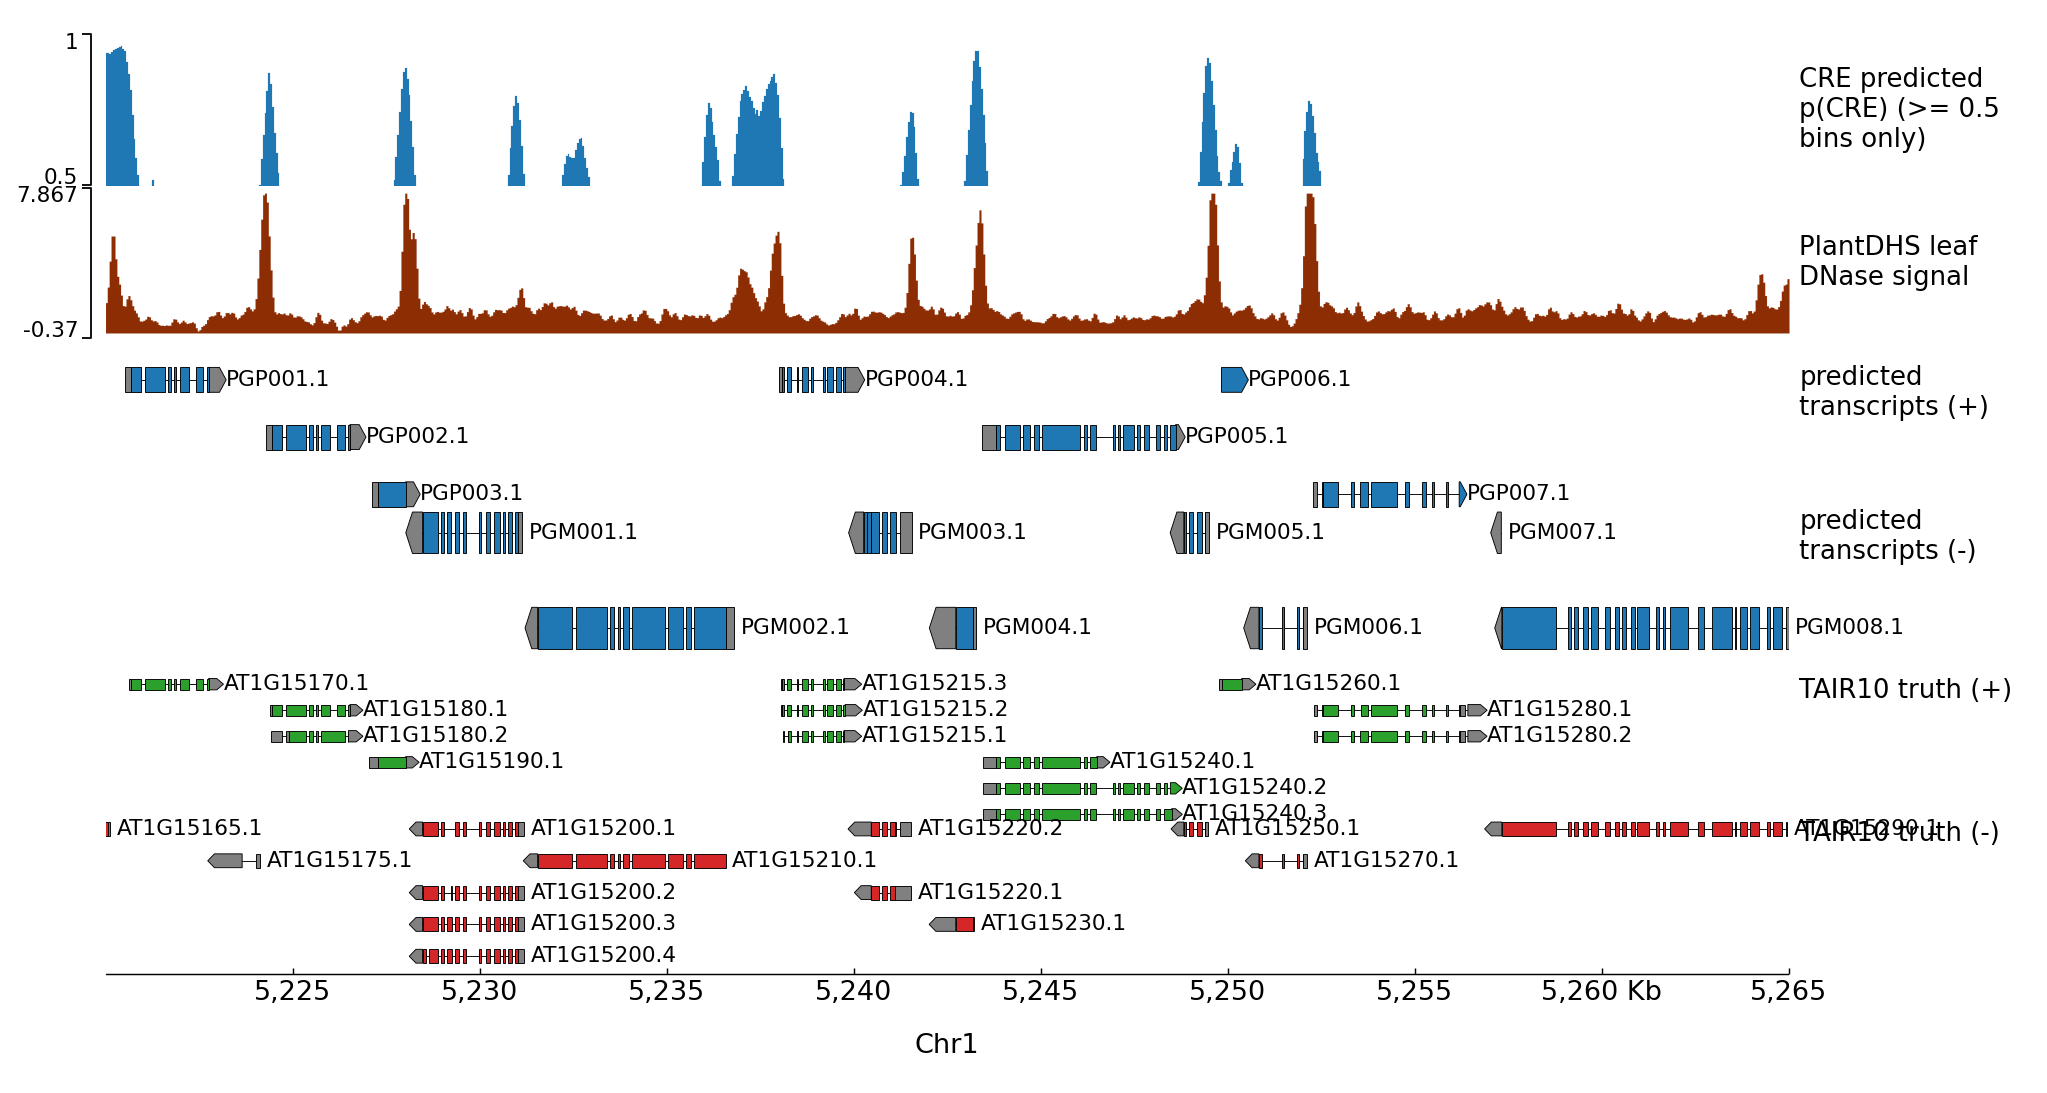

zoom_window=Chr1:5220001-5260000

combined_window=Chr1:5220001-5265000

In [7]:
# Six-track combined view (owner-approved stack, rendered with pygenometracks):
# CRE confident band, official leaf DNase, spacer, predicted transcripts (+/-),
# spacer, TAIR10 truth (+/-), x-axis -- one aligned genomic axis, titles on.
import base64
import subprocess
import sys

from IPython.display import display

pred_plus, pred_minus = pred_paths["+"], pred_paths["-"]
truth_plus, truth_minus = truth_paths["+"], truth_paths["-"]
tracks_ini = outputs_dir / "combined_tracks.ini"
tracks_ini.write_text(
    f"""[CRE predicted p(CRE) confident band]
file = {pcres_path}
height = 3
title = CRE predicted p(CRE) (>= 0.5 bins only)
file_type = bedgraph
color = #1f77b4
min_value = 0.5
max_value = 1

[PlantDHS leaf DNase]
file = data/Ath_leaf_DNase_chr1_5100001_5300000.bedGraph
height = 3
title = PlantDHS leaf DNase signal
file_type = bedgraph
color = #8c2d04

[spacer]
height = 0.5

[Predicted transcripts (+)]
file = {pred_plus}
height = 2.8
title = predicted transcripts (+)
file_type = gtf
color = #1f77b4

[Predicted transcripts (-)]
file = {pred_minus}
height = 2.8
title = predicted transcripts (-)
file_type = gtf
color = #1f77b4

[spacer]
height = 0.5

[TAIR10 truth (+)]
file = {truth_plus}
height = 2.8
title = TAIR10 truth (+)
file_type = gtf
color = #2ca02c

[TAIR10 truth (-)]
file = {truth_minus}
height = 2.8
title = TAIR10 truth (-)
file_type = gtf
color = #d62728

[x-axis]
where = bottom
""",
    encoding="utf-8",
)
combined_png = outputs_dir / "combined_window.png"
subprocess.run(
    [
        str(Path(sys.executable).with_name("pgt")),  # PATH-independent pgt CLI
        "--tracks",
        str(tracks_ini),
        "--region",
        "Chr1:5220001-5265000",
        "--outFileName",
        str(combined_png),
        "--dpi",
        "130",
    ],
    check=True,
)
display(
    {
        "image/png": base64.b64encode(combined_png.read_bytes()).decode("ascii"),
        "text/plain": "pgt combined view over Chr1:5220001-5265000",
    },
    raw=True,
)
print("zoom_window=Chr1:5220001-5260000")
print("combined_window=Chr1:5220001-5265000")


One display region, both modalities: the CRE confident band (only p(CRE) >= 0.5 bins drawn — a
display filter; the full-locus overview in the CRE showcase notebook shows the unfiltered
track), the official PlantDHS leaf DNase signal (committed bedGraph, cropped by the
renderer), predicted transcripts (island decode; transcripts spanning less than 100 bp are
not drawn), and TAIR10 truth gene models (plus strand green, minus strand red; committed
pre-converted GTF), all on one aligned genomic axis. The rendered region extends 5 kb past
the owner-chosen window Chr1:5220001-5260000 so edge-crossing genes complete. Shown for
display clarity; the full-locus metrics in the two showcase notebooks remain the
authoritative claim.

Illustrative locus, not genome-wide accuracy.
